In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
#Q1
df = pd.read_csv("agriculture_yield_dataset.csv")
df.head()

print("Rows and Columns:", df.shape)

print("Column Names:")
print(df.columns.tolist())

print("First 10 Records:")
print(df.head(10))

Rows and Columns: (1500, 8)
Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']
First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3              

In [3]:
#Q2
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [4]:
#Q3
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


Which feature has the highest mean value?  <br>
rainfall_mm

Which feature has the highest standard deviation?<br>
ranifall_mm

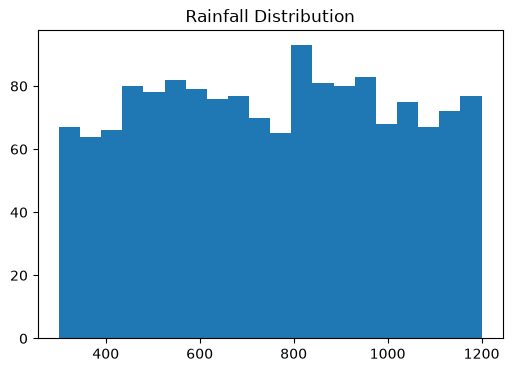

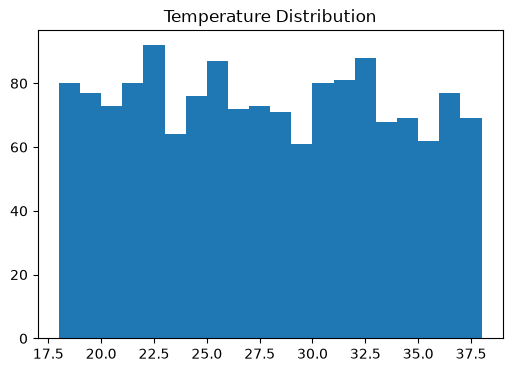

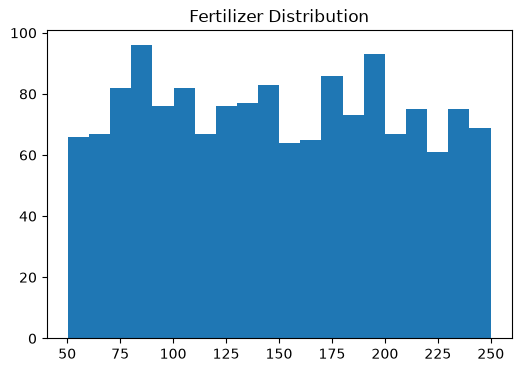

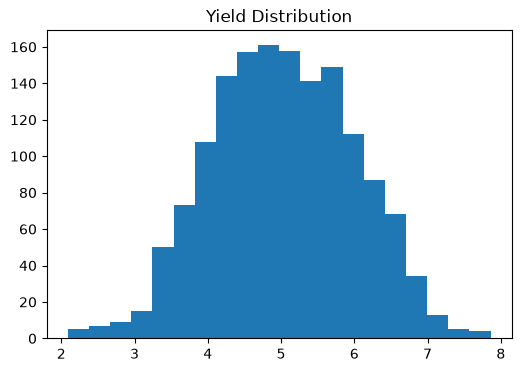

In [5]:
#Q4
plt.figure(figsize=(6,4))
plt.hist(df["rainfall_mm"], bins=20)
plt.title("Rainfall Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["temperature_c"], bins=20)
plt.title("Temperature Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["fertilizer_kg"], bins=20)
plt.title("Fertilizer Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.show()

OBSERVATIONS:

Rainfall is evenly distributed.<br>
Temperature shows uniform spread.<br>
Fertilizer values are spread across range.<br>
Yield follows approximately normal distribution.

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


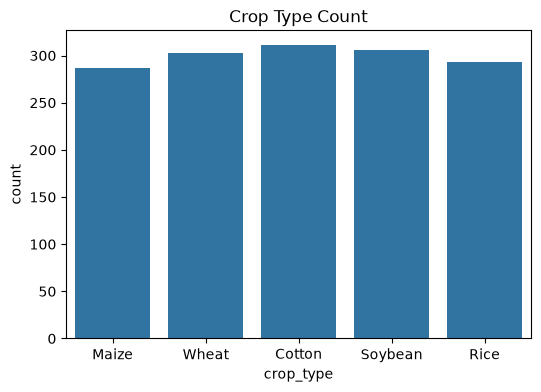

Most Frequent Crop:
Cotton


In [6]:
#Q5
crop_count = df["crop_type"].value_counts()

print(crop_count)

plt.figure(figsize=(6,4))
sns.countplot(x="crop_type", data=df)
plt.title("Crop Type Count")
plt.show()

print("Most Frequent Crop:")
print(df["crop_type"].mode()[0])

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


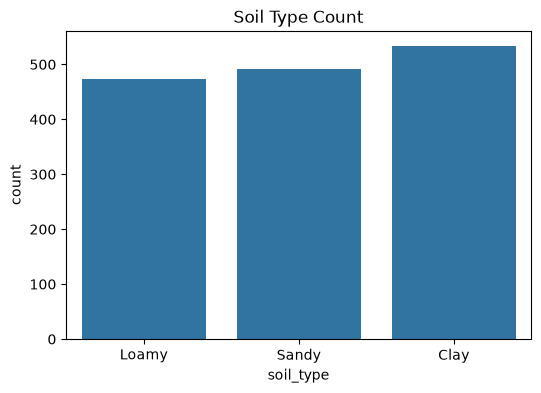

Most Common Soil:
Clay


In [7]:
#Q6
soil_count = df["soil_type"].value_counts()

print(soil_count)

plt.figure(figsize=(6,4))
sns.countplot(x="soil_type", data=df)
plt.title("Soil Type Count")
plt.show()

print("Most Common Soil:")
print(df["soil_type"].mode()[0])

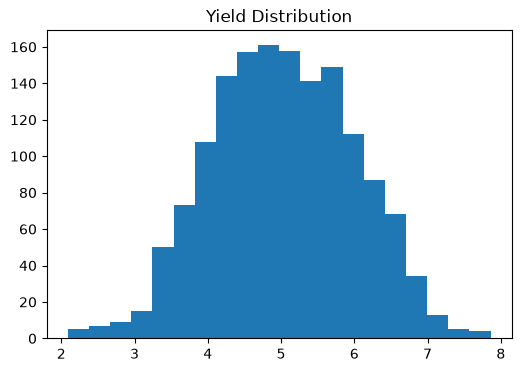

In [8]:
#Q7
plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.show()

Is the distribution approximately normal?  
Distribution is approximately normal.

Are there any noticeable outliers?<br>
No major outliers observed.

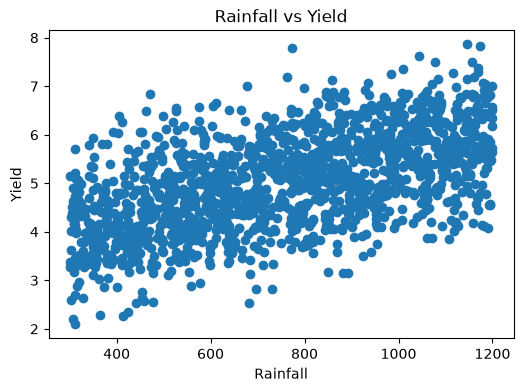

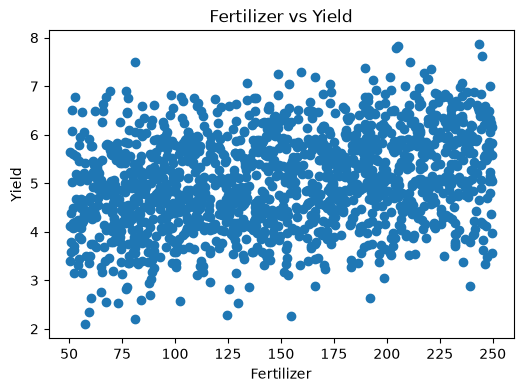

In [9]:
#Q8
plt.figure(figsize=(6,4))
plt.scatter(df["rainfall_mm"],
            df["yield_ton_per_hectare"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["fertilizer_kg"],
            df["yield_ton_per_hectare"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

Which feature appears to have a stronger relationship with yield? <br>
Rainfall shows a stronger relationship with yield.

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

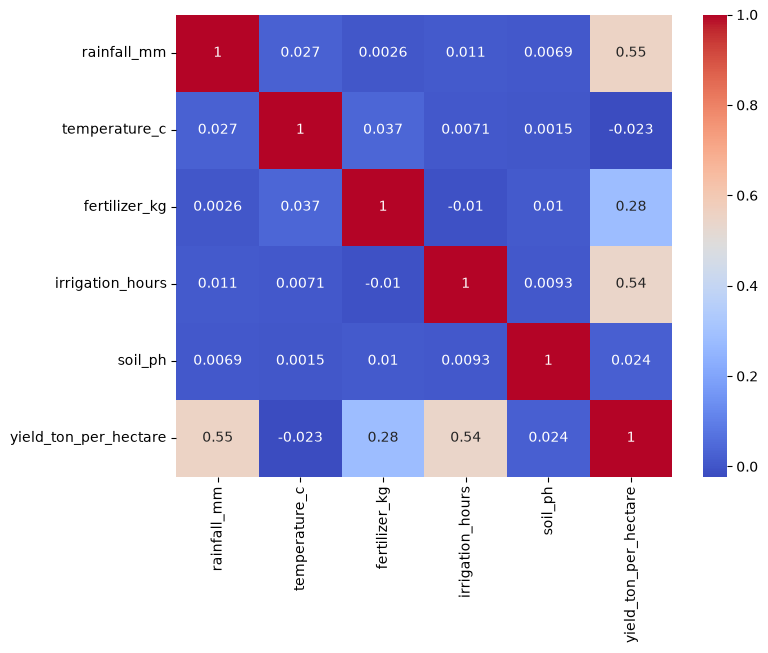

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [10]:
#Q9
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()

print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

yield_corr = corr["yield_ton_per_hectare"].sort_values(ascending=False)

print(yield_corr)

In [11]:
#Q10
crop_yield = df.groupby("crop_type")["yield_ton_per_hectare"].mean()

soil_yield = df.groupby("soil_type")["yield_ton_per_hectare"].mean()

print(crop_yield)

print("\n")

print(soil_yield)

print("\nHighest Yield Crop:")
print(crop_yield.idxmax())

print("\nHighest Yield Soil:")
print(soil_yield.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy


Which crop and soil type have the highest average yield? <br>
Rice (5.495 ton/hectare)

In [12]:
#Q11
df_encoded = pd.get_dummies(
    df,
    columns=["crop_type","soil_type"],
    drop_first=True
)

print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat  soil_type_Loamy  soil_type_Sandy  
0            

In [13]:
#Q12
X = df_encoded.drop(
    "yield_ton_per_hectare",
    axis=1
)

y = df_encoded["yield_ton_per_hectare"]

print("Target Variable:")
print("yield_ton_per_hectare")

Target Variable:
yield_ton_per_hectare


In [14]:
#Q13
X = df_encoded.drop("yield_ton_per_hectare", axis=1)
y = df_encoded["yield_ton_per_hectare"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1200, 11)
X_test Shape: (300, 11)
y_train Shape: (1200,)
y_test Shape: (300,)


In [15]:
#Q14
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nCoefficients:")
print(coef_df)

print("\nFeature with Highest Positive Coefficient:")
print(coef_df.loc[coef_df["Coefficient"].idxmax()])

Intercept:
1.587132027736124

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
